# Network Analysis (retweeted-once backbone) — Pruning & Community Detection

Copy of `01_network_analysis.ipynb` that operates on the networks written by
`02_Processing/02b_influence_and_flow_networks.ipynb` and **does not use the
out-strength threshold**.

**What was wrong in `01`.** Edges in the retweet network point
retweeter → retweeted, so *out*-strength is the number of retweets an author
*made*. Strategy 3 (`prune_by_out_strength_threshold(threshold=1.0)`) therefore
kept the 1,984,599 authors who had retweeted someone, and deleted every author
who was only ever retweeted. Communities, the AMI table, the JSON export and the
social-media maps were all computed on that retweeter set. See
`docs/AUTHOR_AND_NETWORK_PIPELINE_TRACE.md` §5 and §9.

**What this copy does instead.**

1. **Setup** — unchanged.
2. **Parameters** — one cell: which backbone stem to use, which methods, flags.
3. **Load & inspect** the full influence network (optional, slow).
4. **Pruning** — strategies 1 and 2 are kept as optional, direction-neutral
   references. Strategy 3 is replaced by the **in-strength ≥ 1 backbone**
   ("authors retweeted at least once") that `02b` already wrote as
   `Full_RetweetedOnce_Influence.gml` (edges retweeter → retweeted) and
   `Full_RetweetedOnce_InfoFlow.gml` (the transpose). This notebook loads and
   checks them; it does not re-prune.
5. **Community detection** — the same five methods. The three undirected
   methods and directed Leiden run on the influence file; **Infomap runs on the
   information-flow file**, because its random walker follows edge direction
   and must walk the way content travels (retweeted → retweeter).
6. **AMI / ARI** across methods, aligned by author id rather than by vertex
   position, since two different files are involved.
7. **Export** `Full_RetweetedOnce_author_communities.json` =
   `{author_id: {method: community_id}}`.
8. **Disconnect.**

Outputs are written next to the inputs in `Networks/` as
`Full_RetweetedOnce_Influence_<method>.gml` and
`Full_RetweetedOnce_InfoFlow_infomap.gml` (the workflow names files
`<input stem>_<method>.gml`).

# Setup

In [1]:
%%time
import os
from pathlib import Path
import sys

# --- ENVIRONMENT SWITCH ---
# Set to True if running on local machine with Google Drive Desktop mounted
# Set to False if running in Google Colab cloud
RUNNING_LOCALLY = False

if RUNNING_LOCALLY:
  # --- REPO ROOT ON sys.path (so `from src.*` works locally) ---
    _REPO_ROOT = str(Path(os.getcwd()).resolve().parents[1])
    if _REPO_ROOT not in sys.path:
        sys.path.insert(0, _REPO_ROOT)
    # Standard macOS path for Google Drive Desktop
    BASE_PATH = Path('/Volumes/GoogleDrive/My Drive/Colab Projects/AI Public Trust')

else:
    # Google Colab cloud path
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/My Drive/Colab Projects/AI Public Trust')

# Pre-compute critical paths used across notebooks
twits_folder = BASE_PATH / 'Raw Data/Twits/'
test_folder = BASE_PATH / 'Raw Data/'
datasets_folder = BASE_PATH / 'Data Sets'
cleanedds_folder = BASE_PATH / 'Data Sets/Cleaned Data'
networks_folder = BASE_PATH / 'Data Sets/Networks/'
literature_folder = BASE_PATH / 'Literature/'
topic_models_folder = BASE_PATH / 'Models/Topic Modeling/'

Mounted at /content/drive
CPU times: user 1.07 s, sys: 140 ms, total: 1.21 s
Wall time: 21.2 s


## Clone the repo so `src.network.*` imports resolve (Colab only)

On Colab the runtime has no local copy of the repo, so we `git clone` it, `chdir`
into it, and add it to `sys.path`. Both cells are guarded by `if not RUNNING_LOCALLY`,
so they are no-ops when running locally.

In [2]:
%%time
import os
if not RUNNING_LOCALLY:
    print('Running Colab setup shell commands...')
    !git clone https://github.com/IgnacioOQ/twitter_ai.git
else:
    print('Running locally: Skipping Colab shell setup.')

Running Colab setup shell commands...
Cloning into 'twitter_ai'...
remote: Enumerating objects: 1237, done.
remote: Counting objects: 100% (353/353), done.
remote: Compressing objects: 100% (256/256), done.
remote: Total 1237 (delta 185), reused 243 (delta 96), pack-reused 884 (from 1)
Receiving objects: 100% (1237/1237), 23.51 MiB | 32.84 MiB/s, done.
Resolving deltas: 100% (772/772), done.
CPU times: user 7.8 ms, sys: 11.1 ms, total: 18.9 ms
Wall time: 2.11 s


In [3]:
%%time
import sys, os
if not RUNNING_LOCALLY:
    os.chdir('twitter_ai')
    _repo_root = os.getcwd()
    if _repo_root not in sys.path:
        sys.path.insert(0, _repo_root)

CPU times: user 112 µs, sys: 9 µs, total: 121 µs
Wall time: 94.4 µs


In [4]:
%%time
import os
if not RUNNING_LOCALLY:
    print('Running Colab setup shell commands...')
    !pip install igraph leidenalg powerlaw infomap
else:
    print('Running locally: Skipping Colab shell setup.')

Running Colab setup shell commands...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 87.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 64.4 MB/s eta 0:00:00
CPU times: user 1.71 s, sys: 668 ms, total: 2.38 s
Wall time: 8.77 s


In [5]:
%%time
from datetime import datetime, timedelta, timezone
import json
import os
import pickle
import random
import re
import igraph as ig
import leidenalg
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import powerlaw
import pytz
import seaborn as sns
import tqdm
from IPython.display import Javascript
from pathlib import Path

CPU times: user 2.78 s, sys: 174 ms, total: 2.96 s
Wall time: 2.41 s


In [6]:
%%time
from src.network.network_utils import *
from src.network.network_pruning import *
from src.network.network_modularity import *

CPU times: user 29.4 ms, sys: 2.97 ms, total: 32.3 ms
Wall time: 31.9 ms


# Parameters

Every knob of this notebook. `BACKBONE_STEM` selects which pair of `02b`
outputs to analyse; the default is the retweeted-once backbone. The two
`RUN_*` flags gate the slow, direction-neutral cells that only re-create files
already on Drive.

In [7]:
%%time
# --- Which 02b outputs to analyse ------------------------------------------
BACKBONE_STEM = 'Full_RetweetedOnce'     # 02b writes <stem>_Influence.gml and <stem>_InfoFlow.gml
FULL_STEM     = 'Full_Network'           # 02b: Full_Network_Influence.gml (identical to Full_Network.gml)

INFLUENCE_GML = networks_folder / f'{BACKBONE_STEM}_Influence.gml'   # edge retweeter -> retweeted
INFOFLOW_GML  = networks_folder / f'{BACKBONE_STEM}_InfoFlow.gml'    # edge retweeted -> retweeter

# --- Optional slow sections (outputs already exist on Drive) ----------------
RUN_FULL_INSPECTION = False   # section 1: plot_report on the 3.38M-node full network (~10 min)
RUN_STRATEGIES_1_2  = False   # section 2: recompute LWCC.gml and 90TS_LWCC.gml (direction-neutral)

# --- Community detection -----------------------------------------------------
RESOLUTION         = 1.0
UNDIRECTED_METHODS = ['label_propagation', 'louvain', 'leiden_fast']   # run on the undirected collapse
DIRECTED_METHODS   = ['leiden_directed', 'infomap']                    # run on the directed graph as-is

# Which file each method reads. Infomap follows edge direction, so it gets the
# information-flow file; every other method gets the influence file.
METHOD_INPUT = {m: INFLUENCE_GML.name for m in UNDIRECTED_METHODS + ['leiden_directed']}
METHOD_INPUT['infomap'] = INFOFLOW_GML.name

# Where run_modularity_workflow writes each annotated graph: <input stem>_<method>.gml
COMMUNITY_FILES = {m: f'{Path(f).stem}_{m}.gml' for m, f in METHOD_INPUT.items()}
COMMUNITIES_JSON = networks_folder / f'{BACKBONE_STEM}_author_communities.json'

for k, v in [('INFLUENCE_GML', INFLUENCE_GML), ('INFOFLOW_GML', INFOFLOW_GML)]:
    print(f'{k:<14} {v}  exists={v.exists()}')
print('METHOD_INPUT   ', METHOD_INPUT)
print('COMMUNITY_FILES', COMMUNITY_FILES)
print('COMMUNITIES_JSON', COMMUNITIES_JSON)

INFLUENCE_GML  /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_Influence.gml  exists=True
INFOFLOW_GML   /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_InfoFlow.gml  exists=True
METHOD_INPUT    {'label_propagation': 'Full_RetweetedOnce_Influence.gml', 'louvain': 'Full_RetweetedOnce_Influence.gml', 'leiden_fast': 'Full_RetweetedOnce_Influence.gml', 'leiden_directed': 'Full_RetweetedOnce_Influence.gml', 'infomap': 'Full_RetweetedOnce_InfoFlow.gml'}
COMMUNITY_FILES {'label_propagation': 'Full_RetweetedOnce_Influence_label_propagation.gml', 'louvain': 'Full_RetweetedOnce_Influence_louvain.gml', 'leiden_fast': 'Full_RetweetedOnce_Influence_leiden_fast.gml', 'leiden_directed': 'Full_RetweetedOnce_Influence_leiden_directed.gml', 'infomap': 'Full_RetweetedOnce_InfoFlow_infomap.gml'}
COMMUNITIES_JSON /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_author_commun

# 1. Load the full influence network and inspect it (optional)

`Full_Network_Influence.gml` is the full weighted, directed retweet network
(3,379,040 authors, 7,768,720 edges) as written by `02b`; it is identical to
`Full_Network.gml` from the original notebook. `plot_report` takes about ten
minutes on it, so the cell is gated by `RUN_FULL_INSPECTION`.

In [8]:
%%time
if RUN_FULL_INSPECTION:
    gml_file_path = networks_folder / f'{FULL_STEM}_Influence.gml'
    print('Loading Network...', gml_file_path)
    G = nx.read_gml(gml_file_path)
    print(f"Loaded network with {len(G.nodes()):,} nodes and {len(G.edges()):,} edges.")
    plot_report(G)
    del G
else:
    print('RUN_FULL_INSPECTION = False — skipping the full-network report.')

RUN_FULL_INSPECTION = False — skipping the full-network report.
CPU times: user 72 µs, sys: 0 ns, total: 72 µs
Wall time: 75.6 µs


# 2. Pruning

Three backbones. Strategies 1 and 2 ignore edge direction and are kept here
only for reference (gated by `RUN_STRATEGIES_1_2`; their files already exist).
Strategy 3 is where the original notebook went wrong, and is replaced.

| Strategy | Rule | Direction-sensitive? | Output |
| :-- | :-- | :-- | :-- |
| 1 — LWCC only | self-loops removed, largest weakly connected component | no | `LWCC.gml` |
| 2 — total-strength 90 % | drop lowest in+out strength nodes until 10 % of weight is lost, then LWCC | no | `90TS_LWCC.gml` |
| 3 — **retweeted at least once** | self-loops removed, **in-strength ≥ 1 on the influence network**, then LWCC — computed in `02b` | yes: keeps authors who *received* ≥ 1 retweet | `Full_RetweetedOnce_Influence.gml`, `Full_RetweetedOnce_InfoFlow.gml` |

The original Strategy 3 (`prune_by_out_strength_threshold`, `Final_OutThreshold1.gml`)
kept authors who *made* ≥ 1 retweet. It is intentionally absent from this notebook.

## Strategy 1 — Largest weakly connected component (LWCC) only

Baseline: no edges are pruned. We only remove self-loops and keep the LWCC.

In [9]:
%%time
if not RUN_STRATEGIES_1_2:
    print("RUN_STRATEGIES_1_2 = False — LWCC.gml already exists on Drive; flip the flag to recompute.")
else:
    # --- Paths ---
    base = Path(networks_folder)
    in_path  = base / f"{FULL_STEM}_Influence.gml"
    out_gml1 = base / "LWCC.gml"
    out_nx = base / 'LWCC.graphml'

    # --- Load ---
    print(f"Loading graph from: {in_path}")

    g = ig.Graph.Read_GML(str(in_path))

    # --- Remove self-loops ---
    print("\nRemoving self-loops...")
    g_no_loops = g.simplify(loops=True, multiple=False)

    # --- Find LWCC ---
    g_lwcc = g_no_loops.components(mode='weak').giant()

    # --- Save (GML) ---
    try:
        g_lwcc.write_gml(str(out_gml1))  # available in many igraph versions
    except AttributeError:
        g_lwcc.save(str(out_gml1), format="gml")  # portable fallback
        print(f"\nSaved largest component to: {out_gml1}")

    # --- Change to NX ----
    G = ig_to_nx_fast(g_lwcc)

    # Save to GraphML
    nx.write_graphml(G, out_nx)

    # --- Report ---
    print('Report and Plots')
    plot_report(G)

RUN_STRATEGIES_1_2 = False — LWCC.gml already exists on Drive; flip the flag to recompute.
CPU times: user 53 µs, sys: 0 ns, total: 53 µs
Wall time: 56.7 µs


## Strategy 2 — Total-strength pruning (keep 90% of weight)

Delete the lowest total-strength (in + out) nodes until removing another would
drop below 90% of the original total edge weight, then keep the LWCC.

In [10]:
%%time
if not RUN_STRATEGIES_1_2:
    print("RUN_STRATEGIES_1_2 = False — 90TS_LWCC.gml already exists on Drive; flip the flag to recompute.")
else:
    # Strategy 2: prune by total node strength, keeping 90% of total edge weight,
    # then take the LWCC. Writes 90TS_LWCC.gml (igraph) and 90TS_LWCC.graphml (nx).
    base = Path(networks_folder)
    in_path  = base / f"{FULL_STEM}_Influence.gml"
    out_gml1 = base / "90TS_LWCC.gml"
    out_nx   = base / "90TS_LWCC.graphml"

    # --- Load ---
    print(f"Loading graph from: {in_path}")
    g = ig.Graph.Read_GML(str(in_path))

    # --- Prune ---
    print("Pruning...")
    pruned_g = prune_network_by_deletion(g, method='total_strength', percentage_to_keep=0.90)

    # --- Save (GML) ---
    try:
        pruned_g.write_gml(str(out_gml1))
    except AttributeError:
        pruned_g.save(str(out_gml1), format="gml")
        print(f"\nSaved largest component to: {out_gml1}")

    # --- Convert to NetworkX and save GraphML ---
    G = ig_to_nx_fast(pruned_g)
    nx.write_graphml(G, out_nx)

    # --- Report ---
    print('Report and Plots')
    plot_report(G)

RUN_STRATEGIES_1_2 = False — 90TS_LWCC.gml already exists on Drive; flip the flag to recompute.
CPU times: user 79 µs, sys: 0 ns, total: 79 µs
Wall time: 82.5 µs


## Strategy 3 — Authors retweeted at least once (from `02b`)

Load both files written by `02b`, confirm they are transposes of each other
(same author set, same edge count), and report the backbone. The in-strength
check is informational: every node had in-strength ≥ 1 in the full graph, but
inside the backbone some of their retweeters are gone, so the within-backbone
in-strength can be 0.

Full_RetweetedOnce_Influence.gml: 202,710 vertices, 882,530 edges
Full_RetweetedOnce_InfoFlow.gml:  202,710 vertices, 882,530 edges
Transpose check passed: same author set, same number of edges.
Total weight (retweets among backbone authors): 1,269,747
Authors with in-strength  >= 1 inside the backbone: 132,603 of 202,710
Authors with out-strength >= 1 inside the backbone: 143,043 of 202,710
Report and Plots
Report and Plots
Plotting Report
-------------------------
## Network Summary ##
-------------------------
Network Type: Directed
Number of nodes (V): 202710
Number of edges (E): 882530
Is Weighted: True
Average Degree: 4.3537
Density: 0.000021
Gini Coefficient (Degree): 0.7414
Number of Components: Skipped (very large graph)
Number of self-loops: 0
-------------------------

## Detailed Node and Edge Example ##
-----------------------------------
🔍 Inspecting Node: '0'

Attributes of Node '0':
  - id: 0.0
  - label: 897791833383739393

Edges connected to Node '0':
Example Edge: ('

Fitting xmin: 100%|██████████| 476/476 [00:02<00:00, 183.69it/s]


Fit results on the full distribution:
Alpha (α): 2.5042
Xmin (xₘᵢₙ): 59.0000
Sigma (σ): 0.0285

--- 3. Distribution Comparison ---
Power Law vs. Lognormal: Loglikelihood Ratio R=-0.4180, p-value=0.5876
Verdict: Not statistically significant. Cannot conclude one is a better fit than the other.

--- 4. Generating Plot ---
Density of the network: 2.1477378582011688e-05
4.353657934981007
1.0


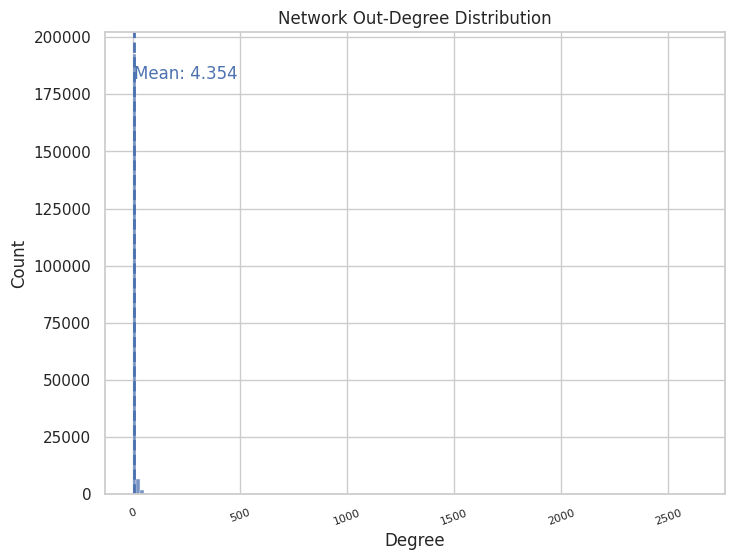

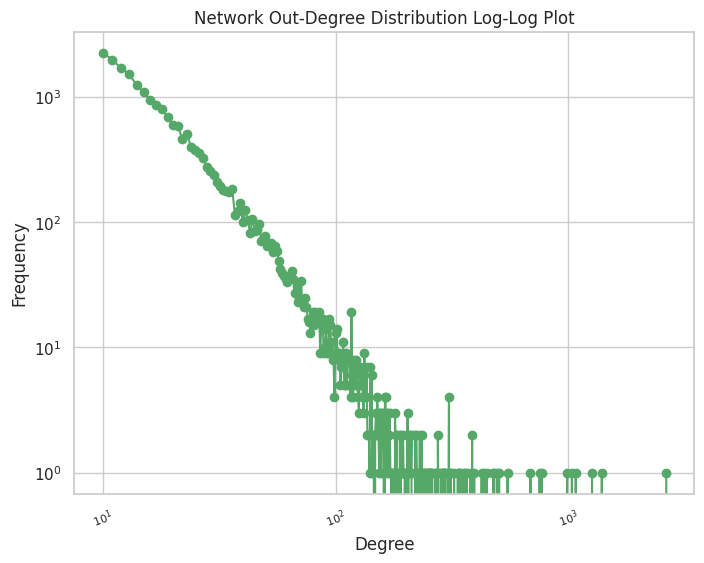

CPU times: user 20.7 s, sys: 887 ms, total: 21.5 s
Wall time: 22.4 s


In [11]:
%%time
g_inf  = ig.Graph.Read_GML(str(INFLUENCE_GML))
g_flow = ig.Graph.Read_GML(str(INFOFLOW_GML))
print(f'{INFLUENCE_GML.name}: {g_inf.vcount():,} vertices, {g_inf.ecount():,} edges')
print(f'{INFOFLOW_GML.name}:  {g_flow.vcount():,} vertices, {g_flow.ecount():,} edges')

# Node identity is the author id stored in the 'label' vertex attribute (GML 'id' is just an index).
labels_inf, labels_flow = set(g_inf.vs['label']), set(g_flow.vs['label'])
assert labels_inf == labels_flow, 'influence and information-flow files hold different author sets'
assert g_inf.ecount() == g_flow.ecount(), 'edge counts differ: the files are not transposes'
assert len(labels_inf) == g_inf.vcount(), 'duplicate author labels in the influence file'
print('Transpose check passed: same author set, same number of edges.')

# Degree semantics on the influence file: in = retweets received, out = retweets made.
in_str  = np.asarray(g_inf.strength(mode='in',  weights='weight'))
out_str = np.asarray(g_inf.strength(mode='out', weights='weight'))
print(f'Total weight (retweets among backbone authors): {in_str.sum():,.0f}')
print(f'Authors with in-strength  >= 1 inside the backbone: {(in_str  >= 1).sum():,} of {g_inf.vcount():,}')
print(f'Authors with out-strength >= 1 inside the backbone: {(out_str >= 1).sum():,} of {g_inf.vcount():,}')

# Standard report on the influence backbone (degree/weight distributions, power-law fit)
print('Report and Plots')
plot_report(ig_to_nx_fast(g_inf))
del g_flow

# 3. Community detection (modularity)

Assign each node a community. `run_modularity_workflow` loads a `.gml`, runs
the chosen algorithm, writes the community IDs back as a `community_<method>`
vertex attribute, saves `<input stem>_<method>.gml`, and reports the number of
communities and the modularity score.

- Reference: https://www.nature.com/articles/s41598-019-41695-z
- Leiden and Louvain both optimise modularity; label propagation is a fast heuristic.
- Background: `kb://content/reference/NETWORK_COMMUNITY_DETECTION_REF.md`.

## Undirected methods — label propagation, Louvain, Leiden (fast)

These three collapse the graph to undirected (reciprocal edges merged, weights
summed), so the edge orientation does not matter and the **influence** file is
used. Each run writes `Full_RetweetedOnce_Influence_<method>.gml`.

In [12]:
%%time
for method in UNDIRECTED_METHODS:
    run_modularity_workflow(
        networks_folder,
        input_filename=METHOD_INPUT[method],
        method=method,
        resolution=RESOLUTION)


MODULARITY WORKFLOW
  Input   : /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_Influence.gml
  Method  : label_propagation
  Resolution : 1.0

1. Loading graph from: /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_Influence.gml
   Vertices: 202,710  Edges: 882,530
   Converted to undirected (collapse, sum weights): 202,710 V  864,436 E

2. Running community detection (label_propagation) ...
   Done.

3. Assigned community IDs as vertex attribute 'communitylabelpropagation'.

4. Saved annotated graph to: /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_Influence_label_propagation.gml

5. Summary
   Number of communities : 4,363
   Modularity            : 0.6819
   Largest 5 communities : [91832, 53195, 8122, 4149, 2977]
   Smallest 5 communities: [2, 2, 2, 2, 2]


MODULARITY WORKFLOW
  Input   : /content/drive/My Drive/Colab Projects/AI Public Trust/Dat

## Directed methods — leidenalg Leiden and Infomap

These run on the directed, weighted graph as-is, so orientation matters:

- **`leiden_directed`** — RBConfiguration quality (modularity + resolution γ),
  seeded. The quality function is invariant under transposition, so it reads
  the **influence** file like the methods above.
- **`infomap`** — the map equation compresses the description of a random walk
  that follows edge direction, so edges must point the way content travels.
  It reads the **information-flow** file (retweeted → retweeter) and writes
  `Full_RetweetedOnce_InfoFlow_infomap.gml`. Its objective is codelength;
  compare it with the others by AMI below, not by modularity.

In [13]:
%%time
for method in DIRECTED_METHODS:
    run_modularity_workflow(
        networks_folder,
        input_filename=METHOD_INPUT[method],
        method=method,
        resolution=RESOLUTION)


MODULARITY WORKFLOW
  Input   : /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_Influence.gml
  Method  : leiden_directed
  Resolution : 1.0

1. Loading graph from: /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_Influence.gml
   Vertices: 202,710  Edges: 882,530

2. Running community detection (leiden_directed) ...
   Done.

3. Assigned community IDs as vertex attribute 'communityleidendirected'.

4. Saved annotated graph to: /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_Influence_leiden_directed.gml

5. Summary
   Number of communities : 1,077
   Modularity            : 0.7441
   Largest 5 communities : [47906, 46415, 18555, 18469, 13446]
   Smallest 5 communities: [2, 2, 2, 2, 2]


MODULARITY WORKFLOW
  Input   : /content/drive/My Drive/Colab Projects/AI Public Trust/Data Sets/Networks/Full_RetweetedOnce_InfoFlow.gml
  Method  : infomap
  Resoluti

## Compare partitions across methods (AMI / ARI)

Modularity only ranks partitions computed under the *same* objective. Adjusted
mutual information (AMI) and adjusted Rand index (ARI) measure how much two
partitions *agree*, independent of objective.

The five annotated files come from **two** source files (influence and
information flow), so membership vectors are aligned by **author id** (the
`label` vertex attribute), not by vertex position. GML round-trips numeric
attributes as floats and drops underscores in attribute names, so the
community attribute is read as `community<method-without-underscores>` and
cast to `int`.

In [14]:
%%time
from itertools import combinations
from sklearn.metrics import adjusted_mutual_info_score, adjusted_rand_score

def read_membership(method):
    # author_id -> community id for one annotated file
    path = networks_folder / COMMUNITY_FILES[method]
    g = ig.Graph.Read_GML(str(path))
    attr = f"community{method.replace('_', '')}"
    out = {str(label): int(c) for label, c in zip(g.vs['label'], g.vs[attr])}
    del g
    return out

memberships = {m: read_membership(m) for m in COMMUNITY_FILES}
authors = sorted(set.intersection(*(set(d) for d in memberships.values())))
sizes = {m: len(d) for m, d in memberships.items()}
assert len(set(sizes.values())) == 1, f'author counts differ across files: {sizes}'
assert len(authors) == next(iter(sizes.values())), 'author sets differ across files'
print(f'{len(authors):,} authors in every partition')

vectors = {m: [memberships[m][a] for a in authors] for m in memberships}
rows = []
for a, b in combinations(vectors, 2):
    rows.append({'method_a': a, 'method_b': b,
                 'AMI': adjusted_mutual_info_score(vectors[a], vectors[b]),
                 'ARI': adjusted_rand_score(vectors[a], vectors[b])})
ami_table = pd.DataFrame(rows).sort_values('AMI', ascending=False).reset_index(drop=True)
ami_table

202,710 authors in every partition
CPU times: user 1min 21s, sys: 486 ms, total: 1min 21s
Wall time: 1min 21s


,method_a,method_b,AMI,ARI
0,leiden_fast,leiden_directed,0.804450,0.846113
1,louvain,leiden_fast,0.756509,0.771006
2,louvain,leiden_directed,0.750519,0.796574
3,label_propagation,leiden_fast,0.571922,0.458000
4,label_propagation,louvain,0.571605,0.518033
5,label_propagation,leiden_directed,0.561997,0.473489
6,leiden_fast,infomap,0.313684,0.007168
7,louvain,infomap,0.311523,0.006410
8,leiden_directed,infomap,0.308617,0.006932
9,label_propagation,infomap,0.258899,0.002224


## Export community memberships as JSON

One JSON dictionary, `Full_RetweetedOnce_author_communities.json` =
`{author_id: {method: community_id}}`, covering all five methods, so downstream
notebooks can restrict themselves to exactly the authors of this backbone and
pick a partition without touching igraph. Per-method projections are trivial
(`{a: d[m] for a, d in combined.items()}`), so no per-method files are written.

Node identity is the author id: `02b` builds the graphs with `str(author_id)`
as the node name, which `nx.write_gml` stores as each vertex's `label`.

In [15]:
%%time
combined = {}   # author_id -> {method: community_id}
for method in COMMUNITY_FILES:
    for author, comm in read_membership(method).items():
        combined.setdefault(author, {})[method] = comm

n_methods = {len(d) for d in combined.values()}
assert n_methods == {len(COMMUNITY_FILES)}, f'some authors are missing a method: {n_methods}'
with open(COMMUNITIES_JSON, 'w') as f:
    json.dump(combined, f)
print(f'Combined: {len(combined):,} authors x {len(COMMUNITY_FILES)} methods -> {COMMUNITIES_JSON.name}')

Combined: 202,710 authors x 5 methods -> Full_RetweetedOnce_author_communities.json
CPU times: user 29.4 s, sys: 407 ms, total: 29.8 s
Wall time: 29.8 s


# 4. Disconnect from the Colab runtime

In [16]:
%%time
import pytz
from IPython.display import Javascript

# Get the current time in the Europe/Berlin timezone
berlin_tz = pytz.timezone('Europe/Berlin')
berlin_time = datetime.now(berlin_tz)

# Print and log
print(f"✅ Disconnected from runtime at: {berlin_time}")

# Disconnect Colab runtime
display(Javascript('google.colab.kernel.disconnect()'))

✅ Disconnected from runtime at: 2026-10-07 20:30:06.872263+02:00


<IPython.core.display.Javascript object>

CPU times: user 11.2 ms, sys: 11.1 ms, total: 22.3 ms
Wall time: 23.3 ms
